In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/naddamuhhamed/sleepy-driver-eeg-brainwave-data/acquiredDataset.csv


In [2]:
#Veri yükleme EEG vverimizi kaggle açık kaynak verilerinden edindik ve projemize dahil ettik
import pandas as pd

# 1. Veriyi yükleme
df = pd.read_csv("/kaggle/input/datasets/naddamuhhamed/sleepy-driver-eeg-brainwave-data/acquiredDataset.csv")

print("================= 1. VERİ SETİ BOYUTU (SHAPE) =================")
print(f"Satır Sayısı: {df.shape[0]} | Sütun Sayısı: {df.shape[1]}")
print("===============================================================\n")

print("================= 2. VERİ SETİ GENEL BİLGİSİ (INFO) =================")
df.info()
print("=====================================================================\n")

print("================= 3. RASTGELE ÖRNEKLEM (SAMPLE) =================")
# Verinin yapısını rastgele 5 satırla kontrol edelim
print(df.sample(5, random_state=42))
print("=================================================================\n")

print("================= 4. EKSİK DEĞER (NaN) KONTROLÜ =================")
print(df.isnull().sum())
print("=================================================================\n")

print("================= 5. TEMEL İSTATİSTİKLER (DESCRIBE) =================")
# Sütun sayısı fazla olduğu için .T (Transpose) ile satır/sütun yerini değiştirip daha okunabilir yapıyoruz
print(df.describe().T)
print("=====================================================================\n")

print("================= 6. HEDEF DEĞİŞKEN DAĞILIMI (CLASS BALANCE) =================")
print("Sayısal Dağılım:")
print(df['classification'].value_counts())
print("\nYüzdesel Oran (Normalize):")
print(df['classification'].value_counts(normalize=True) * 100)
print("==============================================================================")
print(df.isnull().sum())

================= 1. VERİ SETİ BOYUTU (SHAPE) =================
Satır Sayısı: 3735 | Sütun Sayısı: 11

================= 2. VERİ SETİ GENEL BİLGİSİ (INFO) =================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3735 entries, 0 to 3734
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   attention       3735 non-null   int64
 1   meditation      3735 non-null   int64
 2   delta           3735 non-null   int64
 3   theta           3735 non-null   int64
 4   lowAlpha        3735 non-null   int64
 5   highAlpha       3735 non-null   int64
 6   lowBeta         3735 non-null   int64
 7   highBeta        3735 non-null   int64
 8   lowGamma        3735 non-null   int64
 9   highGamma       3735 non-null   int64
 10  classification  3735 non-null   int64
dtypes: int64(11)
memory usage: 321.1 KB

================= 3. RASTGELE ÖRNEKLEM (SAMPLE) =================
      attention  meditation   delta   theta  lowAlpha

'\nBu grafik, beyin dalgaları ile dikkat/meditasyon seviyelerinin birbirleriyle ve uykululuk durumuyla (classification) olan doğrusal ilişkilerini görmemizi sağlayacak.\n'

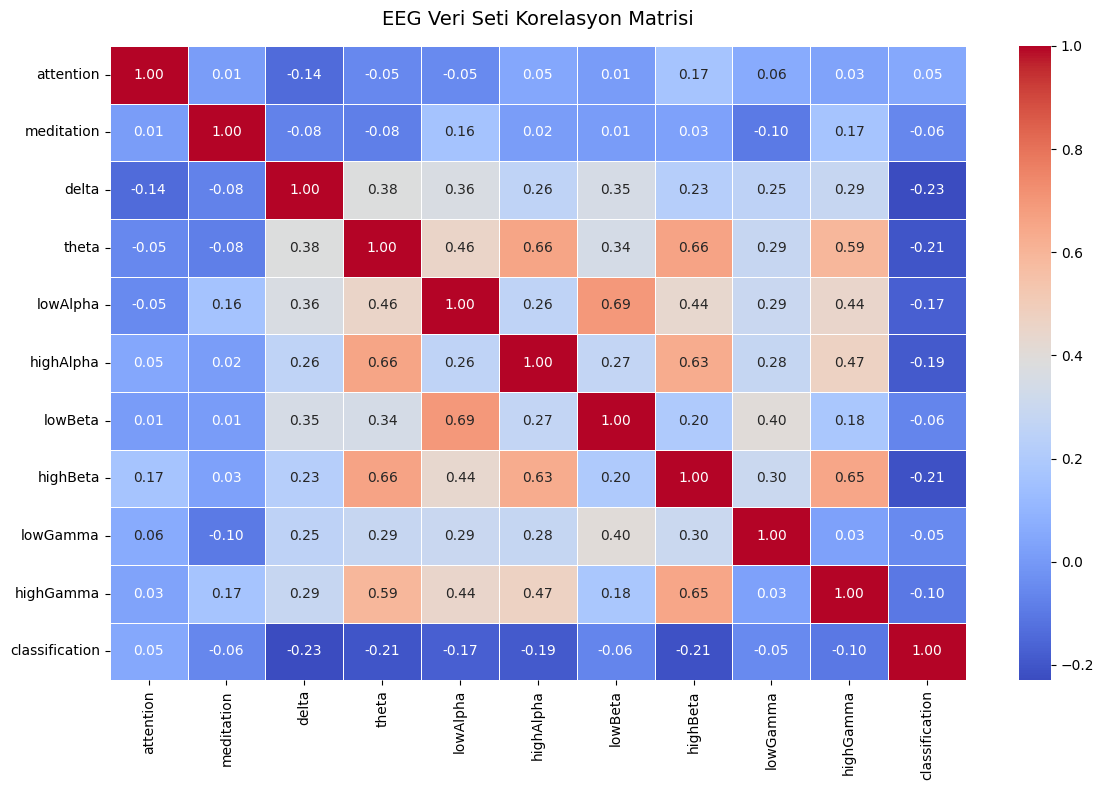

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
""
# 1. Korelasyon Matrisi Heatmap
plt.figure(figsize=(12, 8))

# Tüm sayısal sütunların birbiriyle olan korelasyonunu hesaplayalım
correlation_matrix = df.corr()

# Isı haritasını çizdirelim
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f", 
    linewidths=0.5
)

plt.title("EEG Veri Seti Korelasyon Matrisi", fontsize=14, pad=15)
plt.tight_layout()
plt.show
"""
Bu grafik, beyin dalgaları ile dikkat/meditasyon seviyelerinin birbirleriyle ve uykululuk durumuyla (classification) olan doğrusal ilişkilerini görmemizi sağlayacak.
"""

/tmp/ipykernel_58/2443809728.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x="classification", y="theta", data=df, palette="Set2")
/tmp/ipykernel_58/2443809728.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x="classification", y="attention", data=df, palette="Set2")


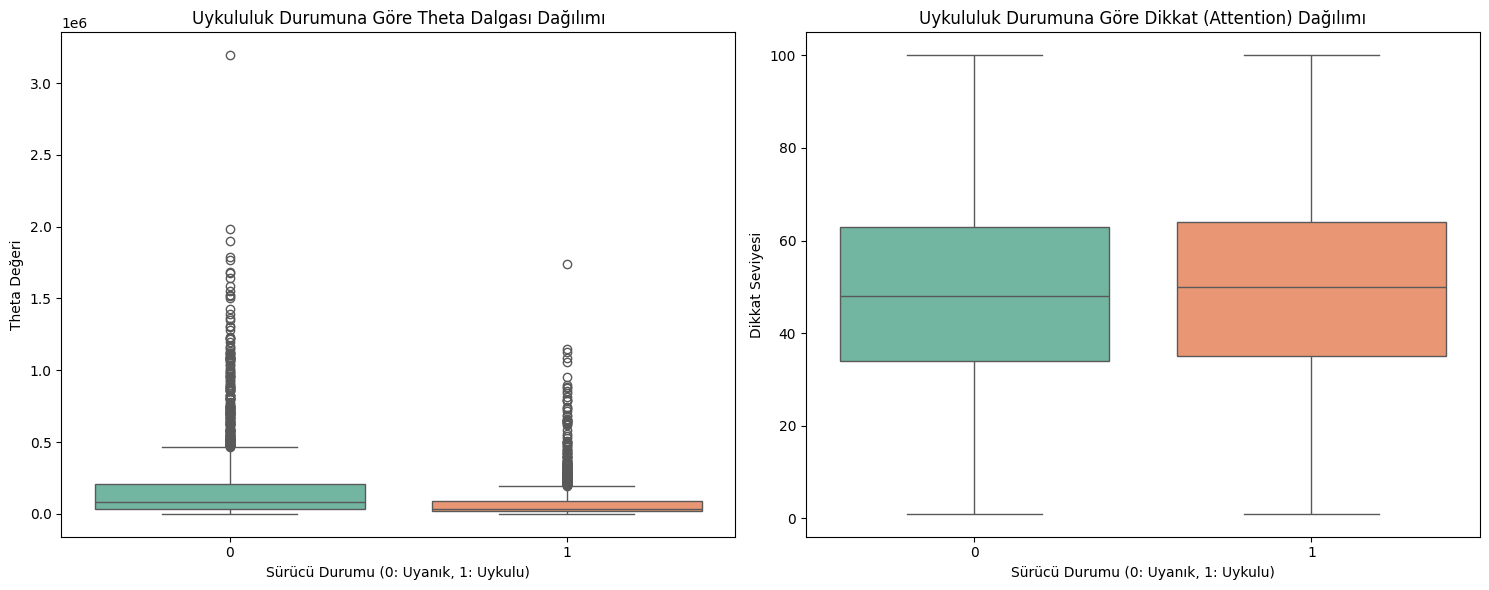

'\nTheta Dalgası ve Attention Seviyesi Dağılımları (Boxplot)\nUykulu ve uyanık sürücülerin Theta beyin dalgaları ve dikkat sürelerindeki farkları net bir şekilde görebilmek için yan yana iki alt grafik (subplot) oluşturuyoruz.\n'

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Theta ve Attention için Boxplot (Yan Yana Subplots)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Sol Grafik: Theta Dalgası Dağılımı (Uykuluyken Theta dalgalarının artması beklenir)
sns.boxplot(ax=axes[0], x="classification", y="theta", data=df, palette="Set2")
axes[0].set_title("Uykululuk Durumuna Göre Theta Dalgası Dağılımı", fontsize=12)
axes[0].set_xlabel("Sürücü Durumu (0: Uyanık, 1: Uykulu)", fontsize=10)
axes[0].set_ylabel("Theta Değeri", fontsize=10)

# Sağ Grafik: Dikkat (Attention) Seviyesi Dağılımı
sns.boxplot(ax=axes[1], x="classification", y="attention", data=df, palette="Set2")
axes[1].set_title("Uykululuk Durumuna Göre Dikkat (Attention) Dağılımı", fontsize=12)
axes[1].set_xlabel("Sürücü Durumu (0: Uyanık, 1: Uykulu)", fontsize=10)
axes[1].set_ylabel("Dikkat Seviyesi", fontsize=10)

plt.tight_layout()
plt.show()
"""
Theta Dalgası ve Attention Seviyesi Dağılımları (Boxplot)
Uykulu ve uyanık sürücülerin Theta beyin dalgaları ve dikkat sürelerindeki farkları net bir şekilde görebilmek için yan yana iki alt grafik (subplot) oluşturuyoruz.
"""

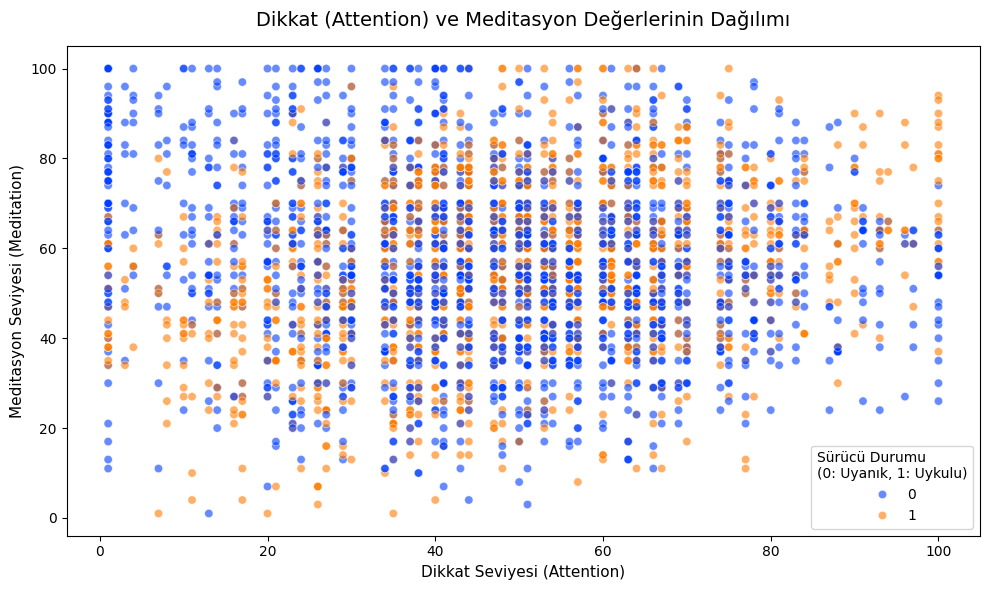

'Attention ve Meditation İlişkisi (Scatterplot)\nSürücülerin odaklanma ve sakinlik durumlarının uykululuk haline göre nasıl kümelendiğini göreceğiz.'

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Attention ve Meditation Dağılımı Scatterplot
plt.figure(figsize=(10, 6))

# Dikkat ve Meditasyon eksenlerinde uykululuk durumuna (classification) göre renklendirme
sns.scatterplot(
    x="attention", 
    y="meditation", 
    hue="classification", 
    data=df, 
    palette="bright", 
    alpha=0.6
)

plt.title("Dikkat (Attention) ve Meditasyon Değerlerinin Dağılımı", fontsize=14, pad=15)
plt.xlabel("Dikkat Seviyesi (Attention)", fontsize=11)
plt.ylabel("Meditasyon Seviyesi (Meditation)", fontsize=11)
plt.legend(title="Sürücü Durumu\n(0: Uyanık, 1: Uykulu)")
plt.tight_layout()
plt.show()
"""Attention ve Meditation İlişkisi (Scatterplot)
Sürücülerin odaklanma ve sakinlik durumlarının uykululuk haline göre nasıl kümelendiğini göreceğiz."""

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Not: Güncel Seaborn sürümlerinde 'shade=True' yerine 'fill=True' kullanılır. 
# İki sürümle de uyumlu olması adına fill=True olarak güncellenmiştir.

# 4. HighBeta ve LowBeta Dağılımları (KDE Plot)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Sol Grafik: LowBeta Yoğunluk Dağılımı
sns.kdeplot(
    data=df, x="lowBeta", hue="classification", 
    fill=True, common_norm=False, palette="crest", alpha=0.5, ax=axes[0]
)
axes[0].set_title("Uykulu ve Uyanık Gruplar için LowBeta Dağılımı", fontsize=12)
axes[0].set_xlabel("LowBeta Değeri", fontsize=10)
axes[0].set_ylabel("Yoğunluk (Density)", fontsize=10)

# Sağ Grafik: HighBeta Yoğunluk Dağılımı
sns.kdeplot(
    data=df, x="highBeta", hue="classification", 
    fill=True, common_norm=False, palette="flare", alpha=0.5, ax=axes[1]
)
axes[1].set_title("Uykulu ve Uyanık Gruplar için HighBeta Dağılımı", fontsize=12)
axes[1].set_xlabel("HighBeta Değeri", fontsize=10)
axes[1].set_ylabel("Yoğunluk (Density)", fontsize=10)

plt.tight_layout()
plt.show()

"""HighBeta ve LowBeta Yoğunluk Dağılımları (KDE Plot)
Beta dalgaları aktif düşünme ve dikkatle ilgilidir. lowBeta ve highBeta değerlerinin uykulu ve uyanık gruplarda nasıl değiştiğini, 
üst üste binen alan grafikleriyle incelemek en sağlıklısıdır.
Grafiklerin birbirine karışmaması adına bunu da yan yana iki subplot olarak kurguladık:"

SyntaxError: incomplete input (1839585990.py, line 31)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# 1. Veri Hazırlığı: Zayıf metrikleri ve hedef değişkeni ayıralım
# --- ÖZELLİK MÜHENDİSLİĞİ & LOG DÖNÜŞÜMÜ ---
# Modeli uçuracak yeni oranı ekliyoruz (Sıfıra bölünme hatasını önlemek için 1e-5 ekliyoruz)
df["theta_beta_ratio"] = df["theta"] / (df["highBeta"] + 1e-5)

# Çarpık (skewed) büyük dalgalara log dönüşümü uygulayarak normalleştiriyoruz
for col in ["delta", "theta", "lowAlpha", "highAlpha", "lowBeta", "highBeta"]:
    df[col + "_log"] = np.log1p(df[col])

# Eski ham dalgaları ve çöp metrikleri drop edip yeni loglu/oranlı verileri bırakıyoruz
X = df.drop(
    columns=[
        "attention",
        "meditation",
        "classification",
        "delta",
        "theta",
        "lowAlpha",
        "highAlpha",
        "lowBeta",
        "highBeta",
    ]
)
y = df["classification"]

# 2. Veri Setini Bölme (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- YENİ: XGBoost Sınıf Dengesizliği Çözümü ---
# Uyanık (0) sayısını Uykulu (1) sayısına bölerek XGBoost için ağırlık oranını buluyoruz.
# Bu formül, modelin "Uykulu" sınıfını yakalama hassasiyetini (Recall) doğrudan artırır.
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

# 3. Modelin Kurulması ve Eğitilmesi (XGBoost)
# Daha derin ilişkileri yakalamak için parametreleri güçlendirdik
model = XGBClassifier(
    n_estimators=200,              # Ormandaki ağaç sayısı (RandomForest'a göre daha fazla olabilir)
    max_depth=6,                   # Her bir ağacın inebileceği maksimum derinlik
    learning_rate=0.1,             # Modelin öğrenme hızı
    scale_pos_weight=scale_weight, # Uykulu sınıfına odaklanma ağırlığı
    random_state=42,
    eval_metric="logloss"          # XGBoost'un arka plan uyarılarını temiz tutmak için
)
model.fit(X_train, y_train)

# 4. Model Tahminleri
y_pred = model.predict(X_test)

# 5. Performans Değerlendirme Metrikleri
print("================ XGBOOST MODEL PERFORMANS RAPORU ================")
print(
    classification_report(
        y_test, y_pred, target_names=["Uyanık (0)", "Uykulu (1)"]
    )
)
print("=================================================================\n")

# 6. Hata Matrisi (Confusion Matrix) Görselleştirmesi
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
# Isı Haritası Kodları 
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Uyanık (0)", "Uykulu (1)"],
    yticklabels=["Uyanık (0)", "Uykulu (1)"],
)
plt.title("XGBoost Hata Matrisi (Confusion Matrix)", fontsize=12, pad=15)
plt.ylabel("Gerçek Durum", fontsize=10)
plt.xlabel("Tahmin Edilen Durum", fontsize=10)
plt.tight_layout()
plt.show()

================ MODEL PERFORMANS RAPORU ================
              precision    recall  f1-score   support

  Uyanık (0)       0.77      0.85      0.81       427
  Uykulu (1)       0.76      0.67      0.71       320

    accuracy                           0.77       747
   macro avg       0.77      0.76      0.76       747
weighted avg       0.77      0.77      0.77       747




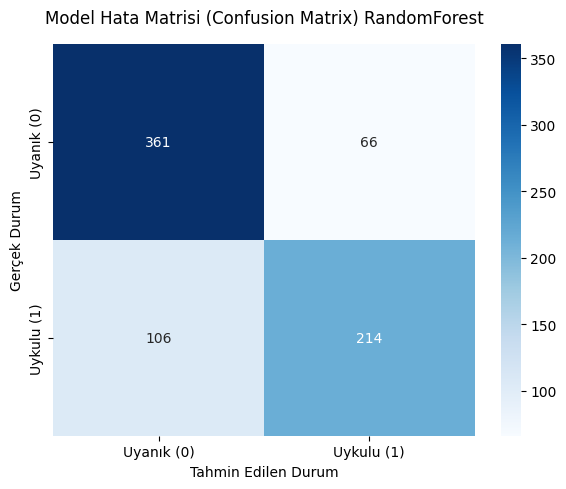

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# --- YENİ: ÖZELLİK MÜHENDİSLİĞİ & LOG DÖNÜŞÜMÜ ---
# 
df["theta_beta_ratio"] = df["theta"] / (df["highBeta"] + 1e-5)

# Çarpık (skewed) büyük dalgalara log dönüşümü uygulayarak normalleştiriyoruz
for col in ["delta", "theta", "lowAlpha", "highAlpha", "lowBeta", "highBeta"]:
    df[col + "_log"] = np.log1p(df[col])

# Eski ham dalgaları ve çöp metrikleri drop edip yeni loglu/oranlı verileri bırakıyoruz
X = df.drop(
    columns=[
        "attention",
        "meditation",
        "classification",
        "delta",
        "theta",
        "lowAlpha",
        "highAlpha",
        "lowBeta",
        "highBeta",
    ]
)
y = df["classification"]

# 2. Veri Setini Bölme (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Modelin Kurulması ve Eğitilmesi
# --- YENİ: class_weight='balanced' PARAMETRESİ EKLENDİ ---
model = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", random_state=42
)
model.fit(X_train, y_train)

# 4. Model Tahminleri
y_pred = model.predict(X_test)

# 5. Performans Değerlendirme Metrikleri
print("================ MODEL PERFORMANS RAPORU ================")
print(
    classification_report(
        y_test, y_pred, target_names=["Uyanık (0)", "Uykulu (1)"]
    )
)
print("=========================================================\n")

# 6. Hata Matrisi (Confusion Matrix) Görselleştirmesi
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Uyanık (0)", "Uykulu (1)"],
    yticklabels=["Uyanık (0)", "Uykulu (1)"],
)
plt.title("Model Hata Matrisi (Confusion Matrix) RandomForest", fontsize=12, pad=15)
plt.ylabel("Gerçek Durum", fontsize=10)
plt.xlabel("Tahmin Edilen Durum", fontsize=10)
plt.tight_layout()
plt.show()